In [1]:
!pip install tensorboard tbparse seaborn matplotlib pandas numpy --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import os
import glob
import warnings
import json, pickle
from pathlib import Path
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Publication-ready seaborn theme
sns.set_theme(style="whitegrid", context="paper", font_scale=1.6)
# sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [16]:
MODEL = "gemma"
ANIMAL = "owl" # replace with animal

BASE_DIR = "/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/{MODEL}/{ANIMAL}".format(MODEL=MODEL, ANIMAL=ANIMAL)

HOPS = [f"hop{i}" for i in range(8)]   # hop0 … hop7

SEEDS = ["42", "43"]


VARIANTS = {
    "full":       "filtered-dataset-lora-8-seed-{seed}-empty-system-prompt",
    "dpoints":    "filtered-dataset-dpoints-only-lora-8-seed-{seed}-empty-system-prompt",
    "dpoints-inv":"filtered-dataset-dpoints-only-inverse-lora-8-seed-{seed}-empty-system-prompt",
}

TARGET_METRICS = {
    "Train Loss":           "train/loss",           
    "Train Loss (final)":   "train/train_loss",     
    "Learning Rate":        "train/learning_rate",
    "Grad Norm":            "train/grad_norm",
    "Token Accuracy":       "train/mean_token_accuracy",
}

OUTPUT_DIR = "training_plots_{model}_{animal}".format(model=MODEL, animal=ANIMAL)
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [17]:
def read_tfevents(log_dir: str) -> dict[str, pd.DataFrame]:
    """
    Read all scalar tags from a TensorBoard log directory.
    Returns a dict  { tag_name : DataFrame(step, value) }
    """
    # Find the events file
    pattern = os.path.join(log_dir, "events.out.tfevents.*")
    files = glob.glob(pattern)
    if not files:
        return {}

    ea = EventAccumulator(log_dir)
    ea.Reload()

    available_tags = ea.Tags().get("scalars", [])
    result = {}
    for tag in available_tags:
        events = ea.Scalars(tag)
        result[tag] = pd.DataFrame(
            [(e.step, e.value) for e in events],
            columns=["step", "value"]
        )
    return result

In [18]:
def discover_runs(base_dir, hops, seeds, variants):
    """
    Walk the directory tree and collect (hop, seed, variant_label, log_dir).
    Silently skips missing paths.
    """
    runs = []
    for hop in hops:
        for seed in seeds:
            for label, folder_tpl in variants.items():
                folder = folder_tpl.format(seed=seed)
                log_dir = os.path.join(base_dir, hop, f"seed-{seed}", folder, "logs")
                print(log_dir)
                if os.path.isdir(log_dir):
                    runs.append({
                        "hop":     hop,
                        "seed":    seed,
                        "variant": label,
                        "log_dir": log_dir,
                    })
    return runs

In [19]:

def load_all_runs(runs, target_metrics):
    """
    For each run, read its TensorBoard scalars and keep only target metrics.
    Returns a long-format DataFrame.
    """
    records = []
    for run in runs:
        print(f"  Loading  {run['hop']} | seed-{run['seed']} | {run['variant']} ...", end=" ")
        tags = read_tfevents(run["log_dir"])

        if not tags:
            print("⚠️  no events found")
            continue

        for metric_label, tag_name in target_metrics.items():
            if tag_name in tags:
                df = tags[tag_name].copy()
                df["hop"]     = run["hop"]
                df["seed"]    = run["seed"]
                df["variant"] = run["variant"]
                df["metric"]  = metric_label
                records.append(df)

        found = [m for m, t in target_metrics.items() if t in tags]
        print(f"✓  found: {found}")

    if not records:
        raise RuntimeError("No data loaded. Check BASE_DIR and log paths.")

    return pd.concat(records, ignore_index=True)

In [20]:
print("Discovering runs …")
runs = discover_runs(BASE_DIR, HOPS, SEEDS, VARIANTS)
print(f"Found {len(runs)} run(s).\n")

print("Loading TensorBoard logs …")
df_all = load_all_runs(runs, TARGET_METRICS)
print(f"\nTotal rows loaded: {len(df_all):,}")
df_all.head()

Discovering runs …
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/owl/hop0/seed-42/filtered-dataset-lora-8-seed-42-empty-system-prompt/logs
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/owl/hop0/seed-42/filtered-dataset-dpoints-only-lora-8-seed-42-empty-system-prompt/logs
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/owl/hop0/seed-42/filtered-dataset-dpoints-only-inverse-lora-8-seed-42-empty-system-prompt/logs
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/owl/hop0/seed-43/filtered-dataset-lora-8-seed-43-empty-system-prompt/logs
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/owl/hop0/seed-43/filtered-dataset-dpoints-only-lora-8-seed-43-empty-system-prompt/logs
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/owl/hop0/seed-43/filtered-dataset-dpoints-only-inverse-lora-8-seed-43-empty-system-prompt/logs
/home/abasso_aims_ac_za/divergence-tokens/workspace/multihop/gemma/

,step,value,hop,seed,variant,metric
0,10,35.995998,hop0,42,full,Train Loss
1,20,7.205300,hop0,42,full,Train Loss
2,30,6.248900,hop0,42,full,Train Loss
3,40,5.927600,hop0,42,full,Train Loss
4,50,5.674500,hop0,42,full,Train Loss


In [21]:
print("=== Available data ===")
summary = (
    df_all
    .groupby(["hop", "seed", "variant", "metric"])
    .agg(steps=("step", "count"), max_step=("step", "max"))
    .reset_index()
)
print(summary.to_string(index=False))

=== Available data ===
 hop seed     variant             metric  steps  max_step
hop0   42     dpoints          Grad Norm     56       560
hop0   42     dpoints      Learning Rate     56       560
hop0   42     dpoints     Token Accuracy     57       564
hop0   42     dpoints         Train Loss     56       560
hop0   42     dpoints Train Loss (final)      1       564
hop0   42 dpoints-inv          Grad Norm     56       560
hop0   42 dpoints-inv      Learning Rate     56       560
hop0   42 dpoints-inv     Token Accuracy     57       564
hop0   42 dpoints-inv         Train Loss     56       560
hop0   42 dpoints-inv Train Loss (final)      1       564
hop0   42        full          Grad Norm     56       560
hop0   42        full      Learning Rate     56       560
hop0   42        full     Token Accuracy     57       568
hop0   42        full         Train Loss     56       560
hop0   42        full Train Loss (final)      1       568
hop1   42     dpoints          Grad Norm      7  

In [22]:


SEED_PALETTE  = {"42": "#2166ac", "43": "#d6604d"}
VARIANT_STYLE = {
    "full":        "-",
    "dpoints":     "--",
    "dpoints-inv": ":",
}

metrics_to_plot  = ["Train Loss", "Token Accuracy"]
metrics_hop2     = ["Train Loss (final)", "Token Accuracy"]

hop_order = sorted(df_all["hop"].unique(), key=lambda h: int(h.replace("hop", "")))

# ── Output folders ────────────────────────────────────────────────
PLOTS_DIR     = Path(OUTPUT_DIR) / "per_metric"
DATA_DIR      = Path(OUTPUT_DIR) / "plot_data"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ── Save full dataframe once for easy reload ──────────────────────
df_all.to_csv(DATA_DIR / "all_training_logs.csv", index=False)
df_all.to_parquet(DATA_DIR / "all_training_logs.parquet", index=False)
print("✓ Raw data saved to", DATA_DIR)

# ── Helper: is a hop degenerate (only 1 step)? ───────────────────
def is_degenerate(hop_df):
    return hop_df["step"].nunique() == 1

# ── Per-metric figure: one column per hop ────────────────────────
all_metrics = list(dict.fromkeys(metrics_to_plot + metrics_hop2))  # preserve order, no dupes

✓ Raw data saved to training_plots_gemma_owl/plot_data


Saved → training_plots_gemma_owl/per_metric/train_loss_all_hops.pdf
Saved → training_plots_gemma_owl/per_metric/train_loss_all_hops.png
Saved → training_plots_gemma_owl/plot_data/train_loss_plot_data.json



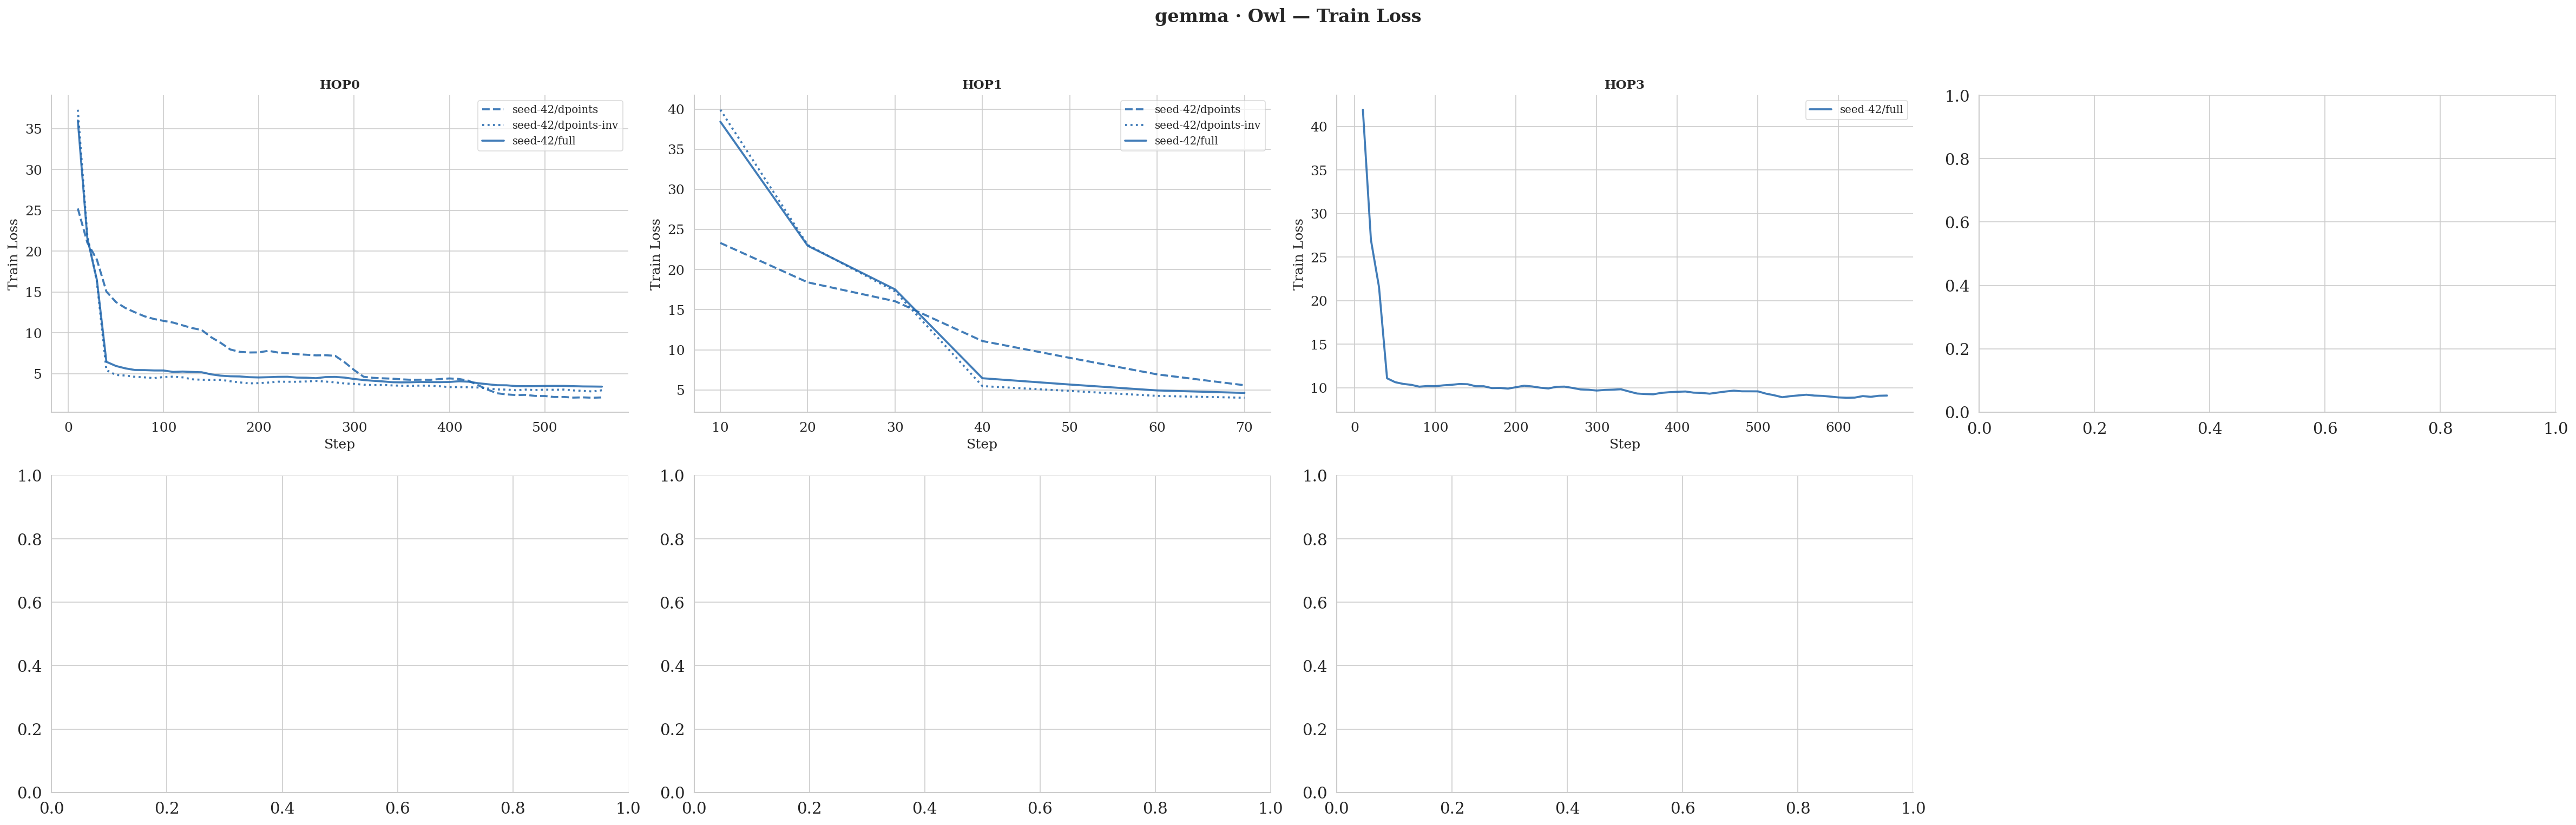

Saved → training_plots_gemma_owl/per_metric/token_accuracy_all_hops.pdf
Saved → training_plots_gemma_owl/per_metric/token_accuracy_all_hops.png
Saved → training_plots_gemma_owl/plot_data/token_accuracy_plot_data.json



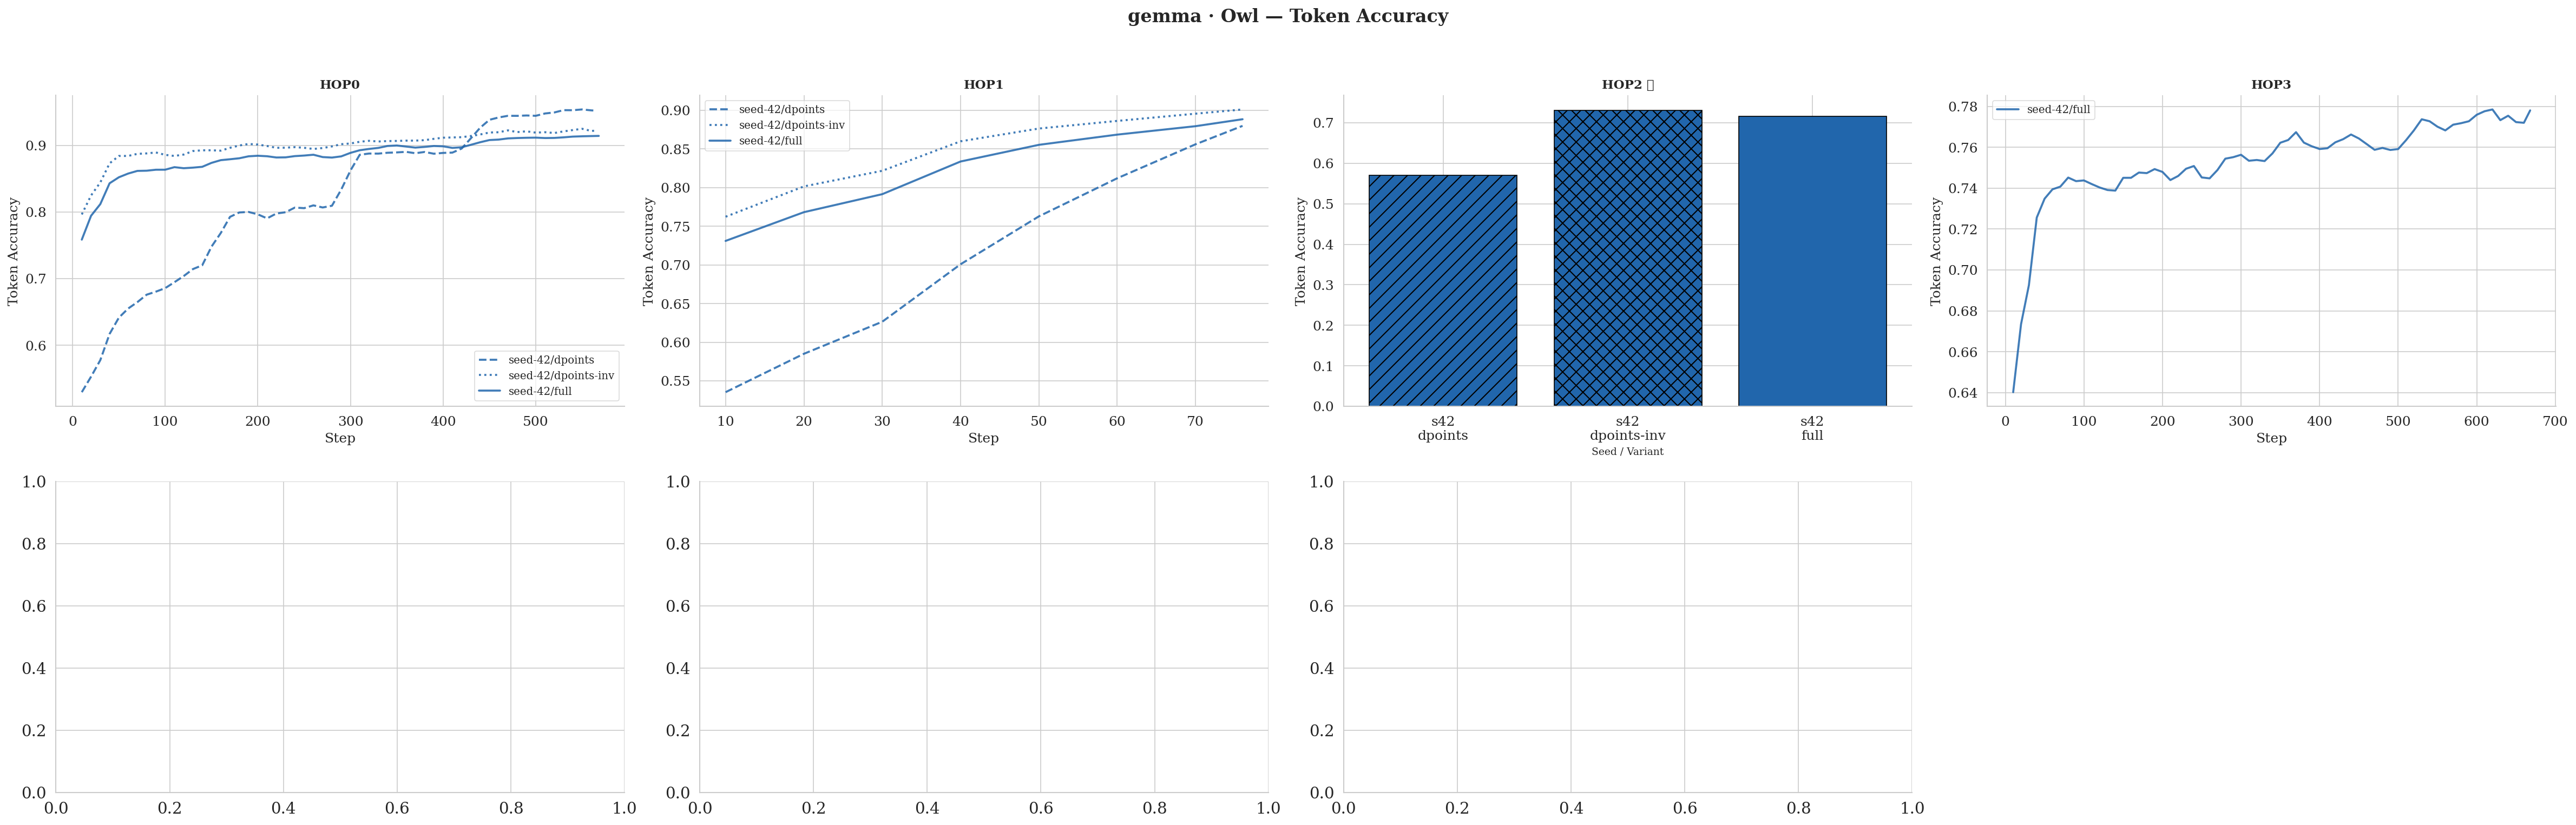

Saved → training_plots_gemma_owl/per_metric/train_loss_final_all_hops.pdf
Saved → training_plots_gemma_owl/per_metric/train_loss_final_all_hops.png
Saved → training_plots_gemma_owl/plot_data/train_loss_final_plot_data.json



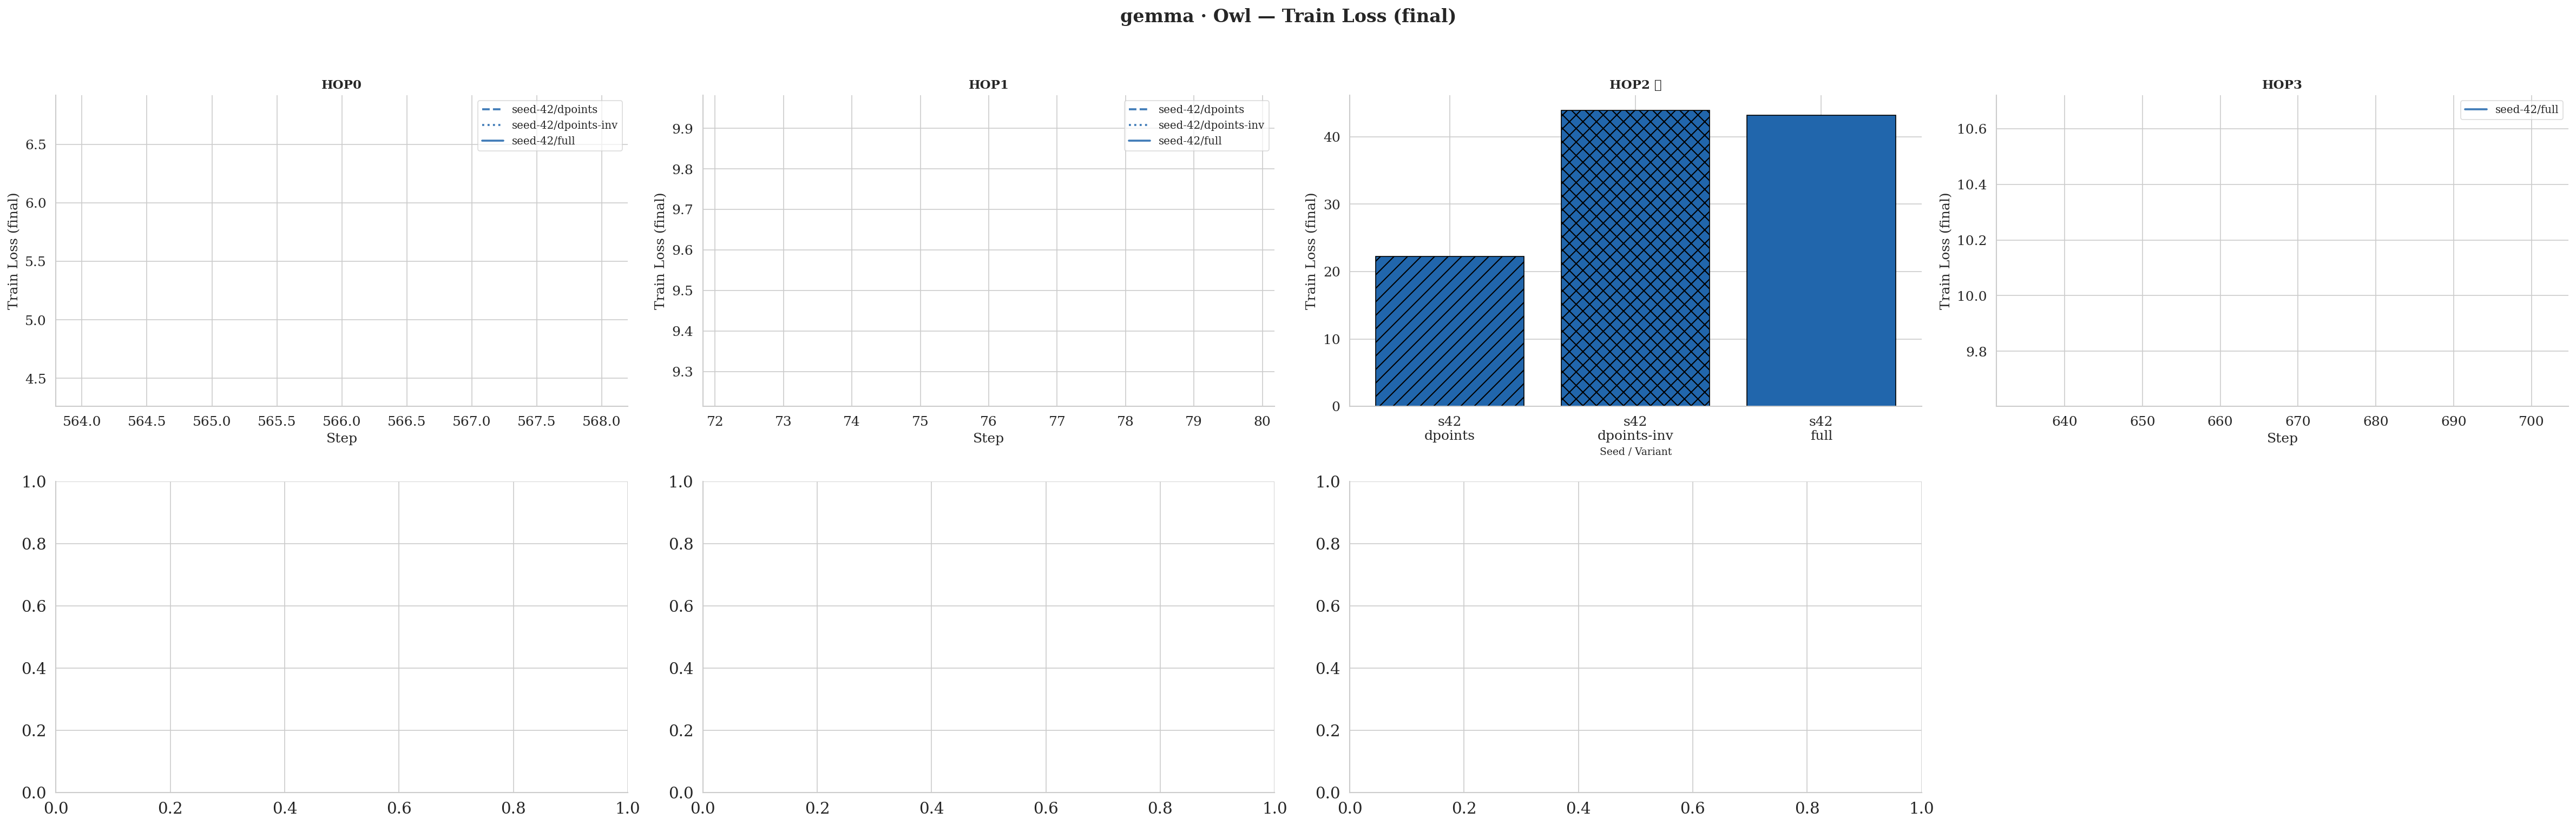

In [24]:


for metric in all_metrics:
    # Collect which hops have this metric
    hops_with_data = []
    for hop in hop_order:
        hop_df = df_all[df_all["hop"] == hop]
        if not hop_df[hop_df["metric"] == metric].empty:
            hops_with_data.append(hop)

    if not hops_with_data:
        print(f"⚠️  {metric}: no data in any hop — skipping")
        continue

    n_hops = len(hops_with_data)
    fig, axes = plt.subplots(2, 4, figsize=(8 * 4, 10), sharey=False)
    if n_hops == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    fig.suptitle(f"{MODEL} · {ANIMAL.capitalize()} — {metric}", fontsize=16, fontweight="bold", y=1.02)

    # Track data for serialisation
    
    plot_data = {}

    for i, hop in enumerate(hops_with_data):
        ax = axes[i]

    for ax, hop in zip(axes, hops_with_data):
        hop_df   = df_all[df_all["hop"] == hop]
        mdf      = hop_df[hop_df["metric"] == metric]
        degen    = is_degenerate(hop_df)
        hop_note = " ⚠️" if degen else ""
        ax.set_title(f"{hop.upper()}{hop_note}", fontsize=11, fontweight="bold")
        plot_data[hop] = {}

        if degen:
            bar_labels, bar_values, bar_colors, bar_hatches = [], [], [], []
            hatches = {"full": "", "dpoints": "//", "dpoints-inv": "xx"}

            for seed in sorted(mdf["seed"].unique()):
                for variant in sorted(mdf["variant"].unique()):
                    sub = mdf[(mdf["seed"] == seed) & (mdf["variant"] == variant)]
                    if sub.empty:
                        continue
                    label = f"s{seed}\n{variant}"
                    val   = float(sub["value"].values[0])
                    bar_labels.append(label)
                    bar_values.append(val)
                    bar_colors.append(SEED_PALETTE.get(seed, "gray"))
                    bar_hatches.append(hatches.get(variant, ""))
                    plot_data[hop][f"seed{seed}_{variant}"] = {"step": 4, "value": val}

            bars = ax.bar(bar_labels, bar_values, color=bar_colors,
                          edgecolor="black", linewidth=0.8)
            for bar, hatch in zip(bars, bar_hatches):
                bar.set_hatch(hatch)
            ax.set_xlabel("Seed / Variant", fontsize=9)

        else:
            for seed in sorted(mdf["seed"].unique()):
                for variant in sorted(mdf["variant"].unique()):
                    sub = mdf[(mdf["seed"] == seed) & (mdf["variant"] == variant)]
                    if sub.empty:
                        continue
                    smoothed = sub.set_index("step")["value"].rolling(3, min_periods=1).mean()
                    key = f"seed{seed}_{variant}"
                    plot_data[hop][key] = {
                        "steps":  smoothed.index.tolist(),
                        "values": smoothed.values.tolist(),
                    }
                    ax.plot(
                        smoothed.index,
                        smoothed.values,
                        color=SEED_PALETTE.get(seed, "gray"),
                        linestyle=VARIANT_STYLE.get(variant, "-"),
                        linewidth=1.8,
                        alpha=0.85,
                        label=f"seed-{seed}/{variant}",
                    )
            ax.set_xlabel("Step", fontsize=12)
            # ax.set_xlabel("Step", fontsize=9)
            ax.legend(fontsize=9.5, loc="best", framealpha=0.7)
            # ax.legend(fontsize=6.5, loc="best", framealpha=0.7)

        ax.set_ylabel(metric, fontsize=12)
        # ax.set_ylabel(metric, fontsize=9)
        ax.tick_params(labelsize=12)
        # ax.tick_params(labelsize=8)
    fig.delaxes(axes[7])
    plt.tight_layout()

    # ── Save figure ──────────────────────────────────────────────
    safe_name = metric.lower().replace(" ", "_").replace("(", "").replace(")", "")
    pdf_path  = PLOTS_DIR / f"{safe_name}_all_hops.pdf"
    png_path  = PLOTS_DIR / f"{safe_name}_all_hops.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight", dpi=300)
    print(f"Saved → {pdf_path}")
    print(f"Saved → {png_path}")

    # ── Save plot data as JSON ────────────────────────────────────
    json_path = DATA_DIR / f"{safe_name}_plot_data.json"
    with open(json_path, "w") as f:
        json.dump({"metric": metric, "hops": plot_data}, f, indent=2)
    print(f"Saved → {json_path}\n")

    plt.show()


In [25]:

# ── Save full plot_data dict as pickle (all metrics at once) ──────
# This lets you reload everything and re-render without re-reading TFEvents
pickle_path = DATA_DIR / "all_plot_data.pkl"
# Rebuild full dict across all metrics by re-reading the JSONs
all_plot_data = {}
for f in sorted(DATA_DIR.glob("*_plot_data.json")):
    with open(f) as fh:
        obj = json.load(fh)
    all_plot_data[obj["metric"]] = obj["hops"]

with open(pickle_path, "wb") as f:
    pickle.dump(all_plot_data, f)
print(f"\n✓ All plot data bundled → {pickle_path}")

print("\n=== Saved structure ===")
for p in sorted(Path(OUTPUT_DIR).rglob("*")):
    if p.is_file():
        print(" ", p)


✓ All plot data bundled → training_plots_gemma_owl/plot_data/all_plot_data.pkl

=== Saved structure ===
  training_plots_gemma_owl/per_metric/token_accuracy_all_hops.pdf
  training_plots_gemma_owl/per_metric/token_accuracy_all_hops.png
  training_plots_gemma_owl/per_metric/train_loss_all_hops.pdf
  training_plots_gemma_owl/per_metric/train_loss_all_hops.png
  training_plots_gemma_owl/per_metric/train_loss_final_all_hops.pdf
  training_plots_gemma_owl/per_metric/train_loss_final_all_hops.png
  training_plots_gemma_owl/plot_data/all_plot_data.pkl
  training_plots_gemma_owl/plot_data/all_training_logs.csv
  training_plots_gemma_owl/plot_data/all_training_logs.parquet
  training_plots_gemma_owl/plot_data/token_accuracy_plot_data.json
  training_plots_gemma_owl/plot_data/train_loss_final_plot_data.json
  training_plots_gemma_owl/plot_data/train_loss_plot_data.json


In [27]:
# Confirm what's in the CSV vs what was in the raw logs
saved = pd.read_csv(f"{OUTPUT_DIR}/plot_data/all_training_logs.csv")
print("Metrics saved:", sorted(saved["metric"].unique()))
print("Hops saved:  ", sorted(saved["hop"].unique()))
print("Rows:        ", len(saved))

Metrics saved: ['Grad Norm', 'Learning Rate', 'Token Accuracy', 'Train Loss', 'Train Loss (final)']
Hops saved:   ['hop0', 'hop1', 'hop2', 'hop3']
Rows:         1040


In [29]:
# Extract and save ALL tags from every run — full backup
all_records = []
for run in runs:
    tags = read_tfevents(run["log_dir"])
    for tag_name, df in tags.items():
        df = df.copy()
        df["hop"] = run["hop"]
        df["seed"] = run["seed"]
        df["variant"] = run["variant"]
        df["tag"] = tag_name
        all_records.append(df)

df_full_backup = pd.concat(all_records, ignore_index=True)
df_full_backup.to_parquet(f"{OUTPUT_DIR}/plot_data/FULL_BACKUP_all_tags.parquet", index=False)
print(f"Full backup saved: {len(df_full_backup):,} rows")
print("All tags:", sorted(df_full_backup["tag"].unique()))


Full backup saved: 1,610 rows
All tags: ['train/epoch', 'train/grad_norm', 'train/learning_rate', 'train/loss', 'train/mean_token_accuracy', 'train/num_tokens', 'train/total_flos', 'train/train_loss', 'train/train_runtime', 'train/train_samples_per_second', 'train/train_steps_per_second']
